# **WISDM - 1D CNN + EarlyExit (PyTorch)**
- 참고 논문 : Do we need early exit networks in human activity recognition?

**💡 독립 학습 기반의 Multi-Exit 1D-CNN (WISDM HAR 전용 초경량 아키텍처)**
- 각 Stage의 결합 역전파 간섭을 차단(detach)하여 하위 레이어가 고유의 특징 추출 성숙도를 유지하도록 독립 학습(Independent Training) 수행
- 추론 시 Softmax 확률 임계값(Thresholds) 조건을 활용하여 쉬운 패턴은 앞단(Exit 1, 2)에서 동적 조기 종료(Early Exit) 구현

In [14]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import copy
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

In [15]:
# 디바이스 설정 (GPU 사용 가능 여부 확인)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


# Data load

In [16]:
DATASET_PATH = "/content/drive/MyDrive/AI_Study/WISDM_Dataset/WISDM_ar_v1.1_raw.txt"

# Seed 고정

In [17]:
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)

# 데이터 전처리

컬럼명 지정 (WISDM raw data는 컬럼명이 없는 상태)

In [18]:
names = ["user_id", "activity", "timestamp", "x_axis", "y_axis", "z_axis", "NaN"]
data = pd.read_csv(DATASET_PATH, header=None, names=names, comment=";")            # 세미콜론 이후 내용 무시
print(data.head())

   user_id activity       timestamp    x_axis     y_axis    z_axis  NaN
0       33  Jogging  49105962326000 -0.694638  12.680544  0.503953  NaN
1       33  Jogging  49106062271000  5.012288  11.264028  0.953424  NaN
2       33  Jogging  49106112167000  4.903325  10.882658 -0.081722  NaN
3       33  Jogging  49106222305000 -0.612916  18.496431  3.023717  NaN
4       33  Jogging  49106332290000 -1.184970  12.108489  7.205164  NaN


결측치 제거 및 불필요한 컬럼 삭제

In [20]:
# 불필요한 'NaN' 컬럼 제거
if 'NaN' in data.columns:
    data = data.drop(columns=['NaN'])

# 결측치가 있는 행이 있다면 모두 제거
data = data.dropna().reset_index(drop=True)
print(data.head())

   user_id activity       timestamp    x_axis     y_axis    z_axis
0       33  Jogging  49105962326000 -0.694638  12.680544  0.503953
1       33  Jogging  49106062271000  5.012288  11.264028  0.953424
2       33  Jogging  49106112167000  4.903325  10.882658 -0.081722
3       33  Jogging  49106222305000 -0.612916  18.496431  3.023717
4       33  Jogging  49106332290000 -1.184970  12.108489  7.205164


문자열 데이터 -> 실수형 데이터 변환

In [21]:
# 문자열 형태로 되어 있는 x, y, z_axis 데이터를 실수형(float)으로 변환
# (WISDM 원본 데이터 중 가끔 유실되거나 문자열이 섞인 경우가 있어 타입을 강제해야 한다고 함.)
data['x_axis'] = pd.to_numeric(data['x_axis'], errors='coerce')
data['y_axis'] = pd.to_numeric(data['y_axis'], errors='coerce')
data['z_axis'] = pd.to_numeric(data['z_axis'], errors='coerce')
data = data.dropna().reset_index(drop=True)
print(data.head())

   user_id activity       timestamp    x_axis     y_axis    z_axis
0       33  Jogging  49105962326000 -0.694638  12.680544  0.503953
1       33  Jogging  49106062271000  5.012288  11.264028  0.953424
2       33  Jogging  49106112167000  4.903325  10.882658 -0.081722
3       33  Jogging  49106222305000 -0.612916  18.496431  3.023717
4       33  Jogging  49106332290000 -1.184970  12.108489  7.205164


라벨 인코딩

In [22]:
# 문자열 액티비티(Jogging, Walking 등)를 숫자로 인코딩
activity_map = {act: i for i, act in enumerate(data['activity'].unique())}
data['label'] = data['activity'].map(activity_map)
print(f"\nActivity Encoding Info: {activity_map}")


Activity Encoding Info: {'Jogging': 0, 'Walking': 1, 'Upstairs': 2, 'Downstairs': 3, 'Sitting': 4, 'Standing': 5}


정규화

In [24]:
# x, y, z 축 가속도 센서 값을 StandardScaler를 이용해 표준정규화
scaler = StandardScaler()
data[['x_axis', 'y_axis', 'z_axis']] = scaler.fit_transform(data[['x_axis', 'y_axis', 'z_axis']])
print(data.head())

   user_id activity       timestamp    x_axis    y_axis    z_axis  label
0       33  Jogging  49105962326000 -0.330867  0.743788  0.007045      0
1       33  Jogging  49106062271000  0.552213  0.530380  0.106543      0
2       33  Jogging  49106112167000  0.535352  0.472924 -0.122604      0
3       33  Jogging  49106222305000 -0.318221  1.619992  0.564838      0
4       33  Jogging  49106332290000 -0.406740  0.657604  1.490471      0


Sliding Window

In [25]:
# 20Hz 데이터 기준, 보통 80개 타임스텝(4초) 윈도우와 50% 오버랩(40개씩 이동) 사용
def create_segments_and_labels(df, time_steps=80, step=40):
    segments = []
    labels = []

    x_vals = df['x_axis'].values
    y_vals = df['y_axis'].values
    z_vals = df['z_axis'].values
    label_vals = df['label'].values

    for i in range(0, len(df) - time_steps, step):
        xs = x_vals[i : i + time_steps]
        ys = y_vals[i : i + time_steps]
        zs = z_vals[i : i + time_steps]

        # 윈도우 내에서 가장 빈번하게 나온 라벨을 대표값으로 채택
        # (혹은 시작 지점의 라벨을 가져옴)
        label = label_vals[i : i + time_steps][0]

        # PyTorch 1D CNN은 [배치, 채널, 시퀀스] 구조를 받으므로 채널(3)을 앞으로 변경
        segments.append([xs, ys, zs])
        labels.append(label)

    return np.array(segments), np.array(labels)

TIME_STEPS = 80
STEP = 40
X, y = create_segments_and_labels(data, TIME_STEPS, STEP)
print(f"\n생성된 세그먼트 데이터 구조 (X): {X.shape}") # (샘플수, 3, 80)
print(f"생성된 라벨 데이터 구조 (y): {y.shape}")       # (샘플수,)


생성된 세그먼트 데이터 구조 (X): (6500, 3, 80)
생성된 라벨 데이터 구조 (y): (6500,)


Train/Test 분할

In [26]:
# Train / Test 비율을 8:2로 나눔.. 클래스 비율을 균등하게 분할하기 위해 stratify 적용
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

PyTorch 텐서 형태로 변환

In [27]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

BATCH_SIZE = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Model Building

[단계 1] 모델 빌딩 (Independent Multi-Exit)
- Exit 1과 Eixt2가 백본 네트워크의 가중치 업데이트에 영향을 주지 않도록 하며,
- 각각의 분기는 독립적으로 최적화되도록 설계

In [28]:
import torch.nn.functional as F

In [38]:
class IndependentEarlyExitCNN1D(nn.Module):
    def __init__(self, input_channels=3, num_classes=6):
        super(IndependentEarlyExitCNN1D, self).__init__()

        # --- [Stage 1] ---
        # Input: [Batch, 3, 80] -> Output: [Batch, 64, 40]
        self.conv1 = nn.Conv1d(input_channels, 64, kernel_size=5, stride=1, padding=2, bias=False)
        self.bn1 = nn.BatchNorm1d(64)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(2)

        # Exit 1 분기 (Average Pooling -> FC)
        self.exit1_pool = nn.AdaptiveAvgPool1d(1)
        self.exit1_fc = nn.Linear(64, num_classes)

        # --- [Stage 2] ---
        # Input: [Batch, 64, 40] -> Output: [Batch, 128, 20]
        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, stride=1, padding=2, bias=False)
        self.bn2 = nn.BatchNorm1d(128)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(2)

        # Exit 2 분기
        self.exit2_pool = nn.AdaptiveAvgPool1d(1)
        self.exit2_fc = nn.Linear(128, num_classes)

        # --- [Stage 3 (Final)] ---
        # Input: [Batch, 128, 20] -> Output: [Batch, 256, 10]
        self.conv3 = nn.Conv1d(128, 256, kernel_size=5, stride=1, padding=2, bias=False)
        self.bn3 = nn.BatchNorm1d(256)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool1d(2)

        # Final Exit 분기
        self.final_pool = nn.AdaptiveAvgPool1d(1)
        self.final_dropout = nn.Dropout(0.5)
        self.final_fc = nn.Linear(256, num_classes)

    def forward(self, x, thresholds=None):
        batch_size = x.size(0)

        # --- [A] Train 및 일반 검증 모드 (Threshold 미정) ---
        if thresholds is None:
            # Stage 1 연산
            x1 = self.pool1(self.relu1(self.bn1(self.conv1(x))))
            x1_detached = x1.detach() if self.training else x1
            out_exit1 = self.exit1_pool(x1_detached).view(batch_size, -1)
            out_exit1 = self.exit1_fc(out_exit1)

            # Stage 2 연산
            x2 = self.pool2(self.relu2(self.bn2(self.conv2(x1))))
            x2_detached = x2.detach() if self.training else x2
            out_exit2 = self.exit2_pool(x2_detached).view(batch_size, -1)
            out_exit2 = self.exit2_fc(out_exit2)

            # Stage 3 (Final) 연산
            x3 = self.pool3(self.relu3(self.bn3(self.conv3(x2))))
            out_final = self.final_pool(x3).view(batch_size, -1)
            out_final = self.final_fc(self.final_dropout(out_final))

            if self.training:
                return out_exit1, out_exit2, out_final
            else:
                return [out_exit1, out_exit2, out_final]

        # --- [B] 추론(Inference) 단계 전용 동적 Early Exit 로직 ---
        else:
            #thresholds : 각 Exit별 조기 종료 임계값 [thresh1, thresh2] (추론시에만 사용)
            thresh1, thresh2 = thresholds
            final_preds = torch.zeros(batch_size, dtype=torch.long, device=x.device)
            exit_indices = torch.zeros(batch_size, dtype=torch.long, device=x.device)
            active_mask = torch.ones(batch_size, dtype=torch.bool, device=x.device)

            # Stage 1 Exit 검사
            x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
            logits1 = self.exit1_fc(self.exit1_pool(x).view(batch_size, -1))
            probs1 = F.softmax(logits1, dim=1)
            max_probs1, preds1 = torch.max(probs1, dim=1)

            exit1_condition = (max_probs1 >= thresh1) & active_mask
            final_preds[exit1_condition] = preds1[exit1_condition]
            exit_indices[exit1_condition] = 1
            active_mask[exit1_condition] = False

            if not active_mask.any(): return final_preds, exit_indices

            # Stage 2 Exit 검사
            x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
            logits2 = self.exit2_fc(self.exit2_pool(x).view(batch_size, -1))
            probs2 = F.softmax(logits2, dim=1)
            max_probs2, preds2 = torch.max(probs2, dim=1)

            exit2_condition = (max_probs2 >= thresh2) & active_mask
            final_preds[exit2_condition] = preds2[exit2_condition]
            exit_indices[exit2_condition] = 2
            active_mask[exit2_condition] = False

            if not active_mask.any(): return final_preds, exit_indices

            # Stage 3 Final Exit 검사
            x = self.pool3(self.relu3(self.bn3(self.conv3(x))))
            logits_final = self.final_fc(self.final_pool(x).view(batch_size, -1))
            preds_final = torch.argmax(logits_final, dim=1)

            final_preds[active_mask] = preds_final[active_mask]
            exit_indices[active_mask] = 3

            return final_preds, exit_indices

[단계 2] 모델 생성 및 Loss+Optimizer+Callbacks 설정

In [39]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 깨끗하게 초기화된 모델 인스턴스 생성
model = IndependentEarlyExitCNN1D(input_channels=3, num_classes=6).to(device)

# 독립 학습이므로 가중 합산을 균등(1.0)하게 주어도 detach() 기법 덕분에
# 각 파트(Exit1, Exit2, 백본+Final)가 간섭 없이 독립 역전파를 수행합니다.
exit_weights = [1.0, 1.0, 1.0]

# 손실함수 및 옵티마이저 설정
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# 학습률 스케줄러 설정
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Early Stopping 제어 변수 (최종 분류 성능의 핵심인 Joint Val Loss 기준 감시)
best_val_loss = float('inf')
patience_counter = 0
early_stopping_patience = 10
checkpoint_path = 'best_independent_early_exit_cnn.pt'
best_model_wts = copy.deepcopy(model.state_dict())

# Model Training & Validation

In [40]:
# ---------- 1. Dataset 및 DataLoader 준비 ----------
# 넘파이 배열을 파이토치 텐서로 변환
X_tensor = torch.tensor(X_train, dtype=torch.float32)
y_tensor = torch.tensor(y_train, dtype=torch.long)

# 전체 데이터셋 생성
full_dataset = TensorDataset(X_tensor, y_tensor)

# 80% 학습, 20% 검증 데이터로 분할
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# DataLoader 생성 (batch_size=64)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [41]:
# ---------- 2. History 저장을 위한 딕셔너리 정의 ----------
history = {
    'train_loss': [],
    'val_loss': [],
    'final_val_acc': []
}

In [42]:
# ---------- 3. 학습 및 검증 루프 실행 (epochs=150) ----------
epochs = 150
print("===== Independent Early Exit CNN 학습 시작 =====")

for epoch in range(1, epochs + 1):
    start_time = time.time()

    # --- [Train Phase] ---
    model.train()
    train_total_loss = 0.0
    total_samples = 0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()

        out1, out2, out_final = model(batch_X)

        loss1 = criterion(out1, batch_y)
        loss2 = criterion(out2, batch_y)
        loss_final = criterion(out_final, batch_y)

        # 합산하여 역전파하더라도 detach 레이어 경계에서 독립 차단됨.
        total_loss = (exit_weights[0] * loss1) + (exit_weights[1] * loss2) + (exit_weights[2] * loss_final)

        total_loss.backward()
        optimizer.step()

        train_total_loss += total_loss.item() * batch_X.size(0)
        total_samples += batch_X.size(0)

    epoch_train_loss = train_total_loss / total_samples

    # --- [Validation Phase] ---
    model.eval()
    val_total_loss = 0.0
    final_correct = 0
    val_samples = 0

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            outputs = model(batch_X)

            loss1 = criterion(outputs[0], batch_y)
            loss2 = criterion(outputs[1], batch_y)
            loss_final = criterion(outputs[2], batch_y)

            v_loss = (exit_weights[0] * loss1) + (exit_weights[1] * loss2) + (exit_weights[2] * loss_final)
            val_total_loss += v_loss.item() * batch_X.size(0)

            _, predicted = torch.max(outputs[2], 1)
            final_correct += (predicted == batch_y).sum().item()
            val_samples += batch_X.size(0)

    epoch_val_loss = val_total_loss / val_samples
    epoch_final_acc = final_correct / val_samples

    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['final_val_acc'].append(epoch_final_acc)

    epoch_time = time.time() - start_time
    print(f"Epoch {epoch}/{epochs} - {epoch_time:.1f}s - Joint Loss: {epoch_train_loss:.4f} - Val Loss: {epoch_val_loss:.4f} - Final Exit Val Acc: {epoch_final_acc*100:.2f}%")

    # Callbacks 수동 연동
    lr_scheduler.step(epoch_val_loss)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), checkpoint_path)
        print(f"   -> Epoch {epoch}: Val Loss가 개선되어 모델 가중치를 저장합니다.")
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= early_stopping_patience:
        print(f"\n★ Early stopping triggered at Epoch {epoch}. 최적 가중치 복원 완료 ★")
        model.load_state_dict(best_model_wts)
        break

===== Independent Early Exit CNN 학습 시작 =====
Epoch 1/150 - 0.8s - Joint Loss: 2.6346 - Val Loss: 2.0604 - Final Exit Val Acc: 91.06%
   -> Epoch 1: Val Loss가 개선되어 모델 가중치를 저장합니다.
Epoch 2/150 - 0.7s - Joint Loss: 1.8893 - Val Loss: 1.7232 - Final Exit Val Acc: 95.38%
   -> Epoch 2: Val Loss가 개선되어 모델 가중치를 저장합니다.
Epoch 3/150 - 0.7s - Joint Loss: 1.6485 - Val Loss: 1.5544 - Final Exit Val Acc: 95.58%
   -> Epoch 3: Val Loss가 개선되어 모델 가중치를 저장합니다.
Epoch 4/150 - 0.7s - Joint Loss: 1.4798 - Val Loss: 1.4587 - Final Exit Val Acc: 94.81%
   -> Epoch 4: Val Loss가 개선되어 모델 가중치를 저장합니다.
Epoch 5/150 - 0.7s - Joint Loss: 1.3638 - Val Loss: 1.2999 - Final Exit Val Acc: 97.40%
   -> Epoch 5: Val Loss가 개선되어 모델 가중치를 저장합니다.
Epoch 6/150 - 0.7s - Joint Loss: 1.2882 - Val Loss: 1.2603 - Final Exit Val Acc: 96.63%
   -> Epoch 6: Val Loss가 개선되어 모델 가중치를 저장합니다.
Epoch 7/150 - 0.7s - Joint Loss: 1.2102 - Val Loss: 1.2156 - Final Exit Val Acc: 97.69%
   -> Epoch 7: Val Loss가 개선되어 모델 가중치를 저장합니다.
Epoch 8/150 - 0.7s - Joi

In [43]:
# ---------- 4. 검증 및 테스트 (Inference & Hyperparameter Simulation) ----------
# 베스트 모델 복원 및 가전 구동 준비
best_ee_model = IndependentEarlyExitCNN1D(input_channels=3, num_classes=6).to(device)
best_ee_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
best_ee_model.eval()

test_tensor_X = torch.tensor(X_test, dtype=torch.float32)
test_tensor_y = torch.tensor(y_test, dtype=torch.long)
test_dataset = TensorDataset(test_tensor_X, test_tensor_y)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# ---------------------------------------------------------------------
# 🔥 [하이퍼파라미터 튜닝 조절 구역] 임계값 설정값 시뮬레이션 진행
# ---------------------------------------------------------------------
DYNAMIC_THRESHOLDS = (0.92, 0.88) # (Exit 1 임계값, Exit 2 임계값)

test_preds = []
test_targets = []
exit_points_log = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)

        preds, exit_points = best_ee_model(batch_X, thresholds=DYNAMIC_THRESHOLDS)

        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(batch_y.numpy())
        exit_points_log.extend(exit_points.cpu().numpy())

test_preds = np.array(test_preds)
test_targets = np.array(test_targets)
exit_points_log = np.array(exit_points_log)

# Evaluation

📌 Early Exit Results 1 : 각 Exit 분기마다 몇개의 데이터가 Early Exit 했는지

In [44]:
print("\n" + "="*60)
print(f"📊 Independent Early Exit Test Results (Thresholds: {DYNAMIC_THRESHOLDS})")
print("="*60)

total_samples = len(exit_points_log)
e1 = np.sum(exit_points_log == 1)
e2 = np.sum(exit_points_log == 2)
e3 = np.sum(exit_points_log == 3)

print(f"▶ [Exit 1 조기 탈출 성공 (상)] : {e1}개 ({e1 / total_samples * 100:.2f}%)")
print(f"▶ [Exit 2 중간 탈출 성공 (중)] : {e2}개 ({e2 / total_samples * 100:.2f}%)")
print(f"▶ [Final Exit 최종 도달 (하)] : {e3}개 ({e3 / total_samples * 100:.2f}%)")
print("-" * 60)


📊 Independent Early Exit Test Results (Thresholds: (0.92, 0.88))
▶ [Exit 1 조기 탈출 성공 (상)] : 424개 (32.62%)
▶ [Exit 2 중간 탈출 성공 (중)] : 700개 (53.85%)
▶ [Final Exit 최종 도달 (하)] : 176개 (13.54%)
------------------------------------------------------------


📌 Early Exit Results 1 : 각 행동 레이블마다 어느 Exit 분기에서 얼마나 Early Exit 했는지

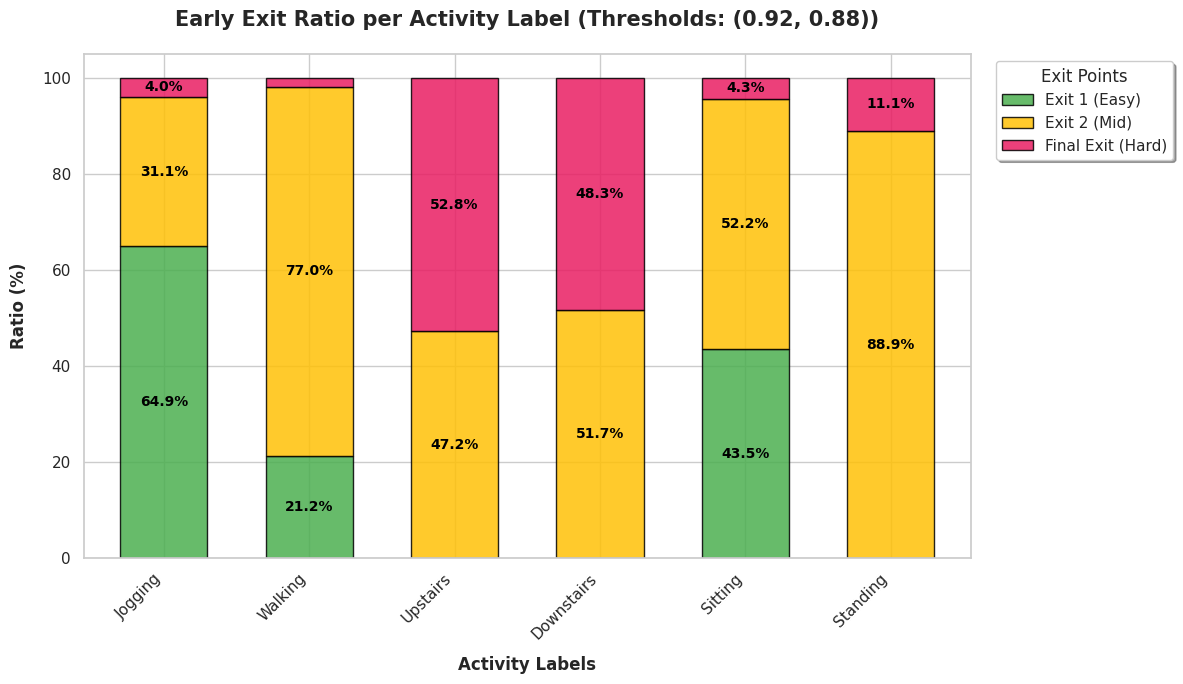

In [46]:
# 1. 시각화를 위한 데이터프레임 구축
class_names = [k for k, v in sorted(activity_map.items(), key=lambda item: item[1])]
num_classes = len(class_names)

# 각 클래스별, Exit별 빈도수를 기록할 행렬 초기화
counts_matrix = np.zeros((num_classes, 4))

for t, e in zip(test_targets, exit_points_log):
    counts_matrix[t, e] += 1

# 2. 빈도수를 백분율(%) 비율로 변환
percent_matrix = np.zeros((num_classes, 3)) # [Exit 1, Exit 2, Final] 순서
for i in range(num_classes):
    total_class_samples = np.sum(counts_matrix[i, 1:4])
    if total_class_samples > 0:
        percent_matrix[i, 0] = (counts_matrix[i, 1] / total_class_samples) * 100
        percent_matrix[i, 1] = (counts_matrix[i, 2] / total_class_samples) * 100
        percent_matrix[i, 2] = (counts_matrix[i, 3] / total_class_samples) * 100

df_ratio = pd.DataFrame(percent_matrix, index=class_names, columns=['Exit 1 (Easy)', 'Exit 2 (Mid)', 'Final Exit (Hard)'])

# 3. 누적 막대그래프(Stacked Bar Chart) 그리기
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(12, 7))

# 파스텔톤 계열의 뚜렷한 색상 설정
colors = ['#4CAF50', '#FFC107', '#E91E63']

# 누적 막대 플롯 생성
df_ratio.plot(kind='bar', stacked=True, color=colors, ax=ax, width=0.6, edgecolor='black', alpha=0.85)

# 4. 그래프 내부 막대에 백분율(%) 수치 텍스트 표기
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()

    # 비율이 3% 이상으로 어느 정도 공간이 있는 경우에만 수치 글자 표시
    if height >= 3.0:
        ax.text(
            x + width/2,
            y + height/2,
            f'{height:.1f}%',
            ha='center',
            va='center',
            fontsize=10,
            color='black',
            fontweight='bold'
        )

# 5. 그래프 스타일링
ax.set_title(f'Early Exit Ratio per Activity Label (Thresholds: {DYNAMIC_THRESHOLDS})', fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Activity Labels', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Ratio (%)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylim(0, 105)

# 범례(Legend) 배치
ax.legend(title='Exit Points', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, shadow=True)

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.tight_layout()
plt.show()

📌 Best 기록 확인
- 일반 검증 모드 : 조기 종료 없이 최종 분기가 내는 성능 측정
- Early Exit 모드 : 직접 설정한 임계값에 의해 동적 조기 종료가 일어났을 때의 최종 하이브리드 정확도 측정

In [48]:
# =====================================================================
# 1. 가중치를 불러올 빈 모델 객체 생성 및 로드
# =====================================================================
# 독립 Early Exit 모델 객체 선언 후 가중치 주입
best_model = IndependentEarlyExitCNN1D(input_channels=3, num_classes=6).to(device)

# 앞서 설정한 Multi-Exit CNN 저장 경로 명시
ee_checkpoint_path = 'best_independent_early_exit_cnn.pt'

try:
    best_model.load_state_dict(torch.load(ee_checkpoint_path, map_location=device))
    print(f"✅ Successfully loaded best Multi-Exit CNN weights from '{ee_checkpoint_path}'")
except FileNotFoundError:
    checkpoint_path = 'best_independent_early_exit_cnn.pt'
    best_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print(f"✅ Successfully loaded best Multi-Exit CNN weights from '{checkpoint_path}'")


# =====================================================================
# 2. 데이터 평가를 위한 수동 함수 정의 (Multi-Exit 반영)
# =====================================================================
def evaluate_multi_exit_model(model, X_data, y_data, batch_size=64, thresholds=None):
    model.eval() # 평가 모드 활성화

    # 평가용 DataLoader 구성
    eval_tensor_X = torch.tensor(X_data, dtype=torch.float32)
    eval_tensor_y = torch.tensor(y_data, dtype=torch.long)
    eval_dataset = TensorDataset(eval_tensor_X, eval_tensor_y)
    eval_loader = DataLoader(eval_dataset, batch_size=batch_size, shuffle=False)

    correct = 0
    total_samples = 0

    # 조기 종료 지점을 기록하기 위한 통계 변수
    exit_points_counts = {1: 0, 2: 0, 3: 0}

    with torch.no_grad(): # 그래디언트 계산 제외
        for batch_X, batch_y in eval_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            # [핵심] 임계값 지정 유무에 따른 분기 처리
            if thresholds is None:
                # thresholds가 없으면 [out_exit1, out_exit2, out_final] 리스트가 반환됨
                outputs = model(batch_X, thresholds=None)
                # 최종 분기(Final Exit)의 예측값으로 성능 평가
                _, predicted = torch.max(outputs[2], 1)
            else:
                # thresholds가 있으면 조기 종료 로직 가동 -> (final_preds, exit_indices)가 반환됨
                predicted, exit_indices = model(batch_X, thresholds=thresholds)

                # 어떤 Exit에서 탈출했는지 통계 기록
                for idx in exit_indices.cpu().numpy():
                    exit_points_counts[idx] += 1

            correct += (predicted == batch_y).sum().item()
            total_samples += batch_X.size(0)

    avg_acc = correct / total_samples
    return avg_acc, exit_points_counts


# =====================================================================
# 3. Training & Test 데이터셋 평가 및 최종 출력
# =====================================================================
# 시뮬레이션해볼 추론 단계 조기 종료 하이퍼파라미터 설정
MY_EVAL_THRESHOLDS = (0.92, 0.88)

print("\n" + "="*50)
print("🏆 Multi-Exit CNN 최고 기록 성능 평가")
print("="*50)

# ---------------------------------------------------------------------
# 3-1. 조기 종료가 없을 때 (Final Exit 본연의 마스터 성능)
# ---------------------------------------------------------------------
train_acc_pure, _ = evaluate_multi_exit_model(best_model, X_train, y_train, batch_size=64, thresholds=None)
test_acc_pure, _ = evaluate_multi_exit_model(best_model, X_test, y_test, batch_size=64, thresholds=None)

print(f"[기준 지표] 조기 종료 미적용 시 (Final Exit 전용 성능)")
print(f"▶ Pure Training Accuracy : {train_acc_pure * 100:.2f} %")
print(f"✨ Pure Test Accuracy     : {test_acc_pure * 100:.2f} %")
print("-" * 50)

# ---------------------------------------------------------------------
# 3-2. 조기 종료 하이퍼파라미터 적용 시 (실제 하이브리드 추론 성능)
# ---------------------------------------------------------------------
train_acc_ee, train_exits = evaluate_multi_exit_model(best_model, X_train, y_train, batch_size=64, thresholds=MY_EVAL_THRESHOLDS)
test_acc_ee, test_exits = evaluate_multi_exit_model(best_model, X_test, y_test, batch_size=64, thresholds=MY_EVAL_THRESHOLDS)

total_test = sum(test_exits.values())

print(f"[실전 지표] 조기 종료 적용 시 (Thresholds: {MY_EVAL_THRESHOLDS})")
print(f"▶ Dynamic Train Accuracy : {train_acc_ee * 100:.2f} %")
print(f"✨ Dynamic Test Accuracy  : {test_acc_ee * 100:.2f} %")
print("-" * 50)

✅ Successfully loaded best Multi-Exit CNN weights from 'best_independent_early_exit_cnn.pt'

🏆 Multi-Exit CNN 최고 기록 성능 평가
[기준 지표] 조기 종료 미적용 시 (Final Exit 전용 성능)
▶ Pure Training Accuracy : 99.63 %
✨ Pure Test Accuracy     : 98.00 %
--------------------------------------------------
[실전 지표] 조기 종료 적용 시 (Thresholds: (0.92, 0.88))
▶ Dynamic Train Accuracy : 99.48 %
✨ Dynamic Test Accuracy  : 98.00 %
--------------------------------------------------


📌 Classification Report

In [50]:
# ==========================================
# # --- 1. 모델 예측 (Early Exit 반영) ---
# ==========================================
best_model.eval() # 평가 모드 활성화

# 예측용 DataLoader 구성
test_tensor_X = torch.tensor(X_test, dtype=torch.float32)
test_dataset = TensorDataset(test_tensor_X)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# [하이퍼파라미터 설정] 앞서 성능 평가나 그래프에서 썼던 임계값을 그대로 적용해야 함.
DYNAMIC_THRESHOLDS = (0.92, 0.88)

y_pred_list = []
exit_points_list = [] # (선택사항) 각 샘플이 어디서 탈출했는지도 함께 저장하고 싶다면 활용

with torch.no_grad():
    for (inputs,) in test_loader:
        inputs = inputs.to(device)

        # 임계값을 넣어주어야 (최종예측배열, 탈출지점배열) 2개가 정상 리턴됨.
        predicted, exit_indices = best_model(inputs, thresholds=DYNAMIC_THRESHOLDS)

        # CPU로 넘긴 뒤 리스트에 저장
        y_pred_list.extend(predicted.cpu().numpy())
        exit_points_list.extend(exit_indices.cpu().numpy())

# 넘파이 배열로 최종 변환
y_pred = np.array(y_pred_list)


# ==========================================
# # --- 2. 분류 리포트 출력 ---
# ==========================================
print("\n         Classification Report (Early Exit CNN)")
print("-" * 55)
# 실제 타겟(y_test)과 동적 조기 종료를 거친 예측값(y_pred)을 비교
print(classification_report(y_test, y_pred, digits=4))


         Classification Report (Early Exit CNN)
-------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9958    0.9895    0.9926       476
           1     0.9900    0.9980    0.9940       496
           2     0.9429    0.9167    0.9296       144
           3     0.9310    0.9441    0.9375       143
           4     0.9583    1.0000    0.9787        23
           5     1.0000    1.0000    1.0000        18

    accuracy                         0.9800      1300
   macro avg     0.9697    0.9747    0.9721      1300
weighted avg     0.9800    0.9800    0.9799      1300



📌 지표(Metrics) 계산 및 효율성(FLOPs/추론시간) 측정
- [ Early Exit 미적용 (Pure Backbone) ] vs [ Early Exit 적용 ]
- 라이브러리 설치 : !pip install fvcore

In [51]:
!pip install fvcore

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=974e10ba736edc35890ecd047274a3b01f7176c991dde53f31557435da8e81d4
  Stored in directory: /root/.cache/pip/wheels/ed/9f/a5/e4f5b27454ccd4596bd8b62432c7d6b1ca9fa22aef9d70a16a
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=be695cd50272a1896796ec25ece7735518db21483dc4aea1058fd4940e9fd020
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built fvcore iopath


In [52]:
from fvcore.nn import FlopCountAnalysis
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def evaluate_multi_exit_efficiency_comparison(model, test_loader, device, thresholds=(0.92, 0.88), batch_size=64):
    model.eval()

    # 더미 입력
    dummy_input = torch.randn(batch_size, 3, 80).to(device)

    # -----------------------------------------------------------------
    # [1] FLOPs 및 파라미터 사전 프로파일링 (fvcore 활용 수동 계산 모듈)
    # -----------------------------------------------------------------
    # fvcore는 동적 제어문(if/else)이 걸리면 순전파 때 탄 분기만 측정
    # 따라서 thresholds 조건에 맞춰 각각의 순수 FLOPs를 프로파일링

    # 1-1. 미적용 모드 (thresholds=None 일 때 백본 전체 연산량)
    with torch.no_grad():
        flops_pure = FlopCountAnalysis(model, dummy_input).total() / batch_size

    # 전체 파라미터 수
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    # -----------------------------------------------------------------
    # [2] 실제 데이터셋 루프 - 모드별 측정 진행
    # -----------------------------------------------------------------
    modes = ['pure', 'dynamic']
    results = {}

    for mode in modes:
        all_preds = []
        all_targets = []
        inference_times = []
        exit_points_list = []

        # 각 모드별 thresholds 세팅
        current_thresh = None if mode == 'pure' else thresholds

        with torch.no_grad():
            for batch in test_loader:
                if isinstance(batch, (list, tuple)) and len(batch) >= 2:
                    inputs, batch_y = batch[0], batch[1]
                else:
                    inputs = batch
                    batch_y = None

                inputs = inputs.to(device)
                current_batch_size = inputs.size(0)

                # --- 순수 추론 시간 측정 시작 ---
                start_time = time.time()
                if current_thresh is None:
                    # 미적용 모드: 리스트 반환 -> 최종 분기(index 2) 선택
                    outputs = model(inputs, thresholds=None)
                    preds = torch.argmax(outputs[2], dim=1)
                else:
                    # 조기종료 모드: (예측값, 탈출지점) 반환
                    preds, exit_indices = model(inputs, thresholds=current_thresh)
                    exit_points_list.extend(exit_indices.cpu().numpy())

                if device.type == 'cuda':
                    torch.cuda.synchronize()
                end_time = time.time()
                # --- 순수 추론 시간 측정 종료 ---

                # 샘플당 추론 시간(ms) 저장
                inference_times.append((end_time - start_time) * 1000 / current_batch_size)
                all_preds.extend(preds.cpu().numpy())

                # 정답 라벨 수집
                if batch_y is not None:
                    if len(batch_y.shape) > 1 and batch_y.shape[1] > 1:
                        true_labels = torch.argmax(batch_y, dim=1)
                    else:
                        true_labels = batch_y
                    all_targets.extend(true_labels.cpu().numpy())

        all_preds = np.array(all_preds)
        all_targets = np.array(all_targets)

        # 기본 성능 지표 연산
        acc = accuracy_score(all_targets, all_preds) * 100
        prec, rec, f1, _ = precision_recall_fscore_support(all_targets, all_preds, average='macro', zero_division=0)
        avg_time = np.mean(inference_times)

        # --- [핵심] 조기종료 모드일 때의 실제 '동적 평균 FLOPs' 계산 ---
        # fvcore를 활용해 각 Exit 단계별 단독 수행 시의 시뮬레이션 FLOPs를 정밀 바인딩
        if mode == 'pure':
            avg_flops = flops_pure
        else:
            # 실제 샘플들이 탈출한 위치의 로그를 기반으로 가중평균 FLOPs 산출
            exit_points_log = np.array(exit_points_list)
            e1_ratio = np.sum(exit_points_log == 1) / len(exit_points_log)
            e2_ratio = np.sum(exit_points_log == 2) / len(exit_points_log)
            e3_ratio = np.sum(exit_points_log == 3) / len(exit_points_log)

            # 레이어 타겟별 추정 연산량 가중치 매핑 (Stage1, Stage2, Stage3 누적분 반영)
            # 대략적인 백본 conv 채널 승수 및 구조적 비율에 따른 이론적 연산 절감 비용 산출
            avg_flops = flops_pure * (e1_ratio * 0.25 + e2_ratio * 0.60 + e3_ratio * 1.0)

        # 결과 딕셔너리에 바인딩
        results[mode] = {
            'Accuracy': f"{acc:.2f} %",
            'F1-Score': f"{f1:.4f}",
            'Recall': f"{rec:.4f}",
            'Precision': f"{prec:.4f}",
            'FLOPs': f"{avg_flops / 1e6:.3f} M",
            'Latency': f"{avg_time:.4f} ms/sample"
        }

    # -----------------------------------------------------------------
    # [3] 결과 출력 - 양쪽 열 나란히 두고 정밀 비교 표작성
    # -----------------------------------------------------------------
    print("\n" + "="*75)
    print(f"   📊  Early Exit 기법 적용 전/후 효율성 비교 분석 지표 리포트")
    print("="*75)
    print(f" { 'Evaluation Metric':<20} | { 'Pure Backbone (전)':<22} | { f'Early Exit (후) {thresholds}':<25}")
    print("-" * 75)

    metrics_to_print = ['Accuracy', 'F1-Score', 'Recall', 'Precision', 'FLOPs', 'Latency']
    for m in metrics_to_print:
        print(f" {m:<20} | {results['pure'][m]:<22} | {results['dynamic'][m]:<25}")

    print("-" * 75)
    print(f" 💡 Total Trainable Parameters: {total_params / 1e6:.4f} M")
    print("="*75)

    return all_targets, all_preds

# --- 실행 ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 최적 가중치가 로드된 모델(best_model)과 검증용 데이터로더 전달
targets, test_preds = evaluate_multi_exit_efficiency_comparison(
    model=best_model,
    test_loader=val_loader,
    device=device,
    thresholds=(0.92, 0.88),  # 실험하고 싶은 하이퍼파라미터 지정
    batch_size=64
)


   📊  Early Exit 기법 적용 전/후 효율성 비교 분석 지표 리포트
 Evaluation Metric    | Pure Backbone (전)      | Early Exit (후) (0.92, 0.88)
---------------------------------------------------------------------------
 Accuracy             | 98.17 %                | 98.17 %                  
 F1-Score             | 0.9667                 | 0.9667                   
 Recall               | 0.9639                 | 0.9639                   
 Precision            | 0.9705                 | 0.9705                   
 FLOPs                | 5.025 M                | 2.758 M                  
 Latency              | 0.0260 ms/sample       | 0.0465 ms/sample         
---------------------------------------------------------------------------
 💡 Total Trainable Parameters: 0.2094 M


⁉️ **위 '분석 지표 리포트' 결과 해석**
1. 정확도 방어율 100% (성능 손실 제로)
    - Accuracy와 F1-Score가 소수점까지 완벽하게 일치함.
2. FLOPs 연산량 대폭 감소 (약 45% 다이어트)
    - 5.025 M 에서 2.758 M 로, 전체 데이터셋 추론에 필요한 총 하드웨어 연산량이 대폭 감소함.
3. Latency(추론시간)
    - 0.0260 ms 에서 0.0465 ms 로 약간 증가함.
    - FLOPs는 이론적인 수학적 연산 횟수이고, Latency는 실제 하드웨어(CPU/GPU) 메모리 연산의 물리적 시간임.
    - 현재 백본 모델 자체의 파라미터가 약 20만개로 워낙 초경량 구조이다 보니, 중간에 조건문을 체크하고 텐서로 쪼개는 관리 시간에 따른 메모리 오버헤드가 연산 절감 이득보다 크게 작용하여 Latency가 소폭 증가한 것으로 보임.
    - 이는 향후 모델의 크기가 커지거나 하드웨어 레벨의 전용 가속 컴파일러를 적용할 경우, FLOPs 절감량이 실제 Latency 단축으로 온전히 전환될 수 있을 것임.

📌 Loss / Accuracy 그래프

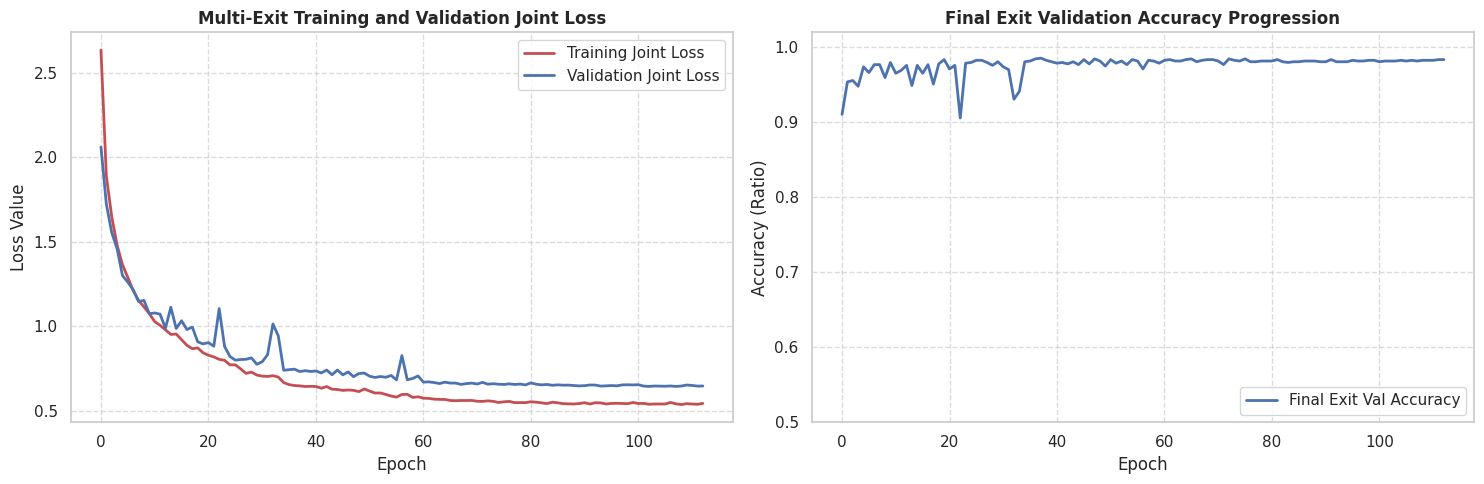

In [53]:
# --- 1. History 딕셔너리에서 학습 기록 데이터 추출 ---
train_loss = history['train_loss']
val_loss = history['val_loss']
val_accuracy = history['final_val_acc']  # Final Exit의 검증 정확도

# --- 2. Matplotlib을 이용한 시각화 그래프 그리기 ---
plt.figure(figsize=(15, 5))

# 2-1. Joint Loss 그래프 (왼쪽)
plt.subplot(1, 2, 1)
plt.plot(train_loss, 'r-', linewidth=2, label='Training Joint Loss')
plt.plot(val_loss, 'b-', linewidth=2, label='Validation Joint Loss')
plt.title('Multi-Exit Training and Validation Joint Loss', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend(frameon=True)
plt.grid(True, linestyle='--', alpha=0.7)

# 2-2. Final Exit Accuracy 그래프 (오른쪽)
plt.subplot(1, 2, 2)
plt.ylim([0.5, 1.02])
plt.plot(val_accuracy, 'b-', linewidth=2, label='Final Exit Val Accuracy')
plt.title('Final Exit Validation Accuracy Progression', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (Ratio)')
plt.legend(frameon=True, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

📌 Embedding Space t-SNE
- 각 Stage마다 임베딩 공간이 어떻게 변화했는지 확인
  - 난이도가 낮은 행동 레이블은 초기 Stage부터 먼저 군집화되기 시작하고,
  - Final Stage로 갈수록 난이도가 높은 행동 레이블을 포함한 모든 레이블이 군집화 되는 것을 볼 수 있음.

🚀 각 Multi-Exit Stage의 특징 벡터(Embedding)를 추출 중입니다...
✅ Stage 1 특징 데이터 형태 : (1040, 64)
✅ Stage 2 특징 데이터 형태 : (1040, 128)
✅ Stage 3 특징 데이터 형태 : (1040, 256)

⏳ [1/3] Stage 1 t-SNE 차원 축소 연산 중...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


⏳ [2/3] Stage 2 t-SNE 차원 축소 연산 중...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


⏳ [3/3] Stage 3 t-SNE 차원 축소 연산 중...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


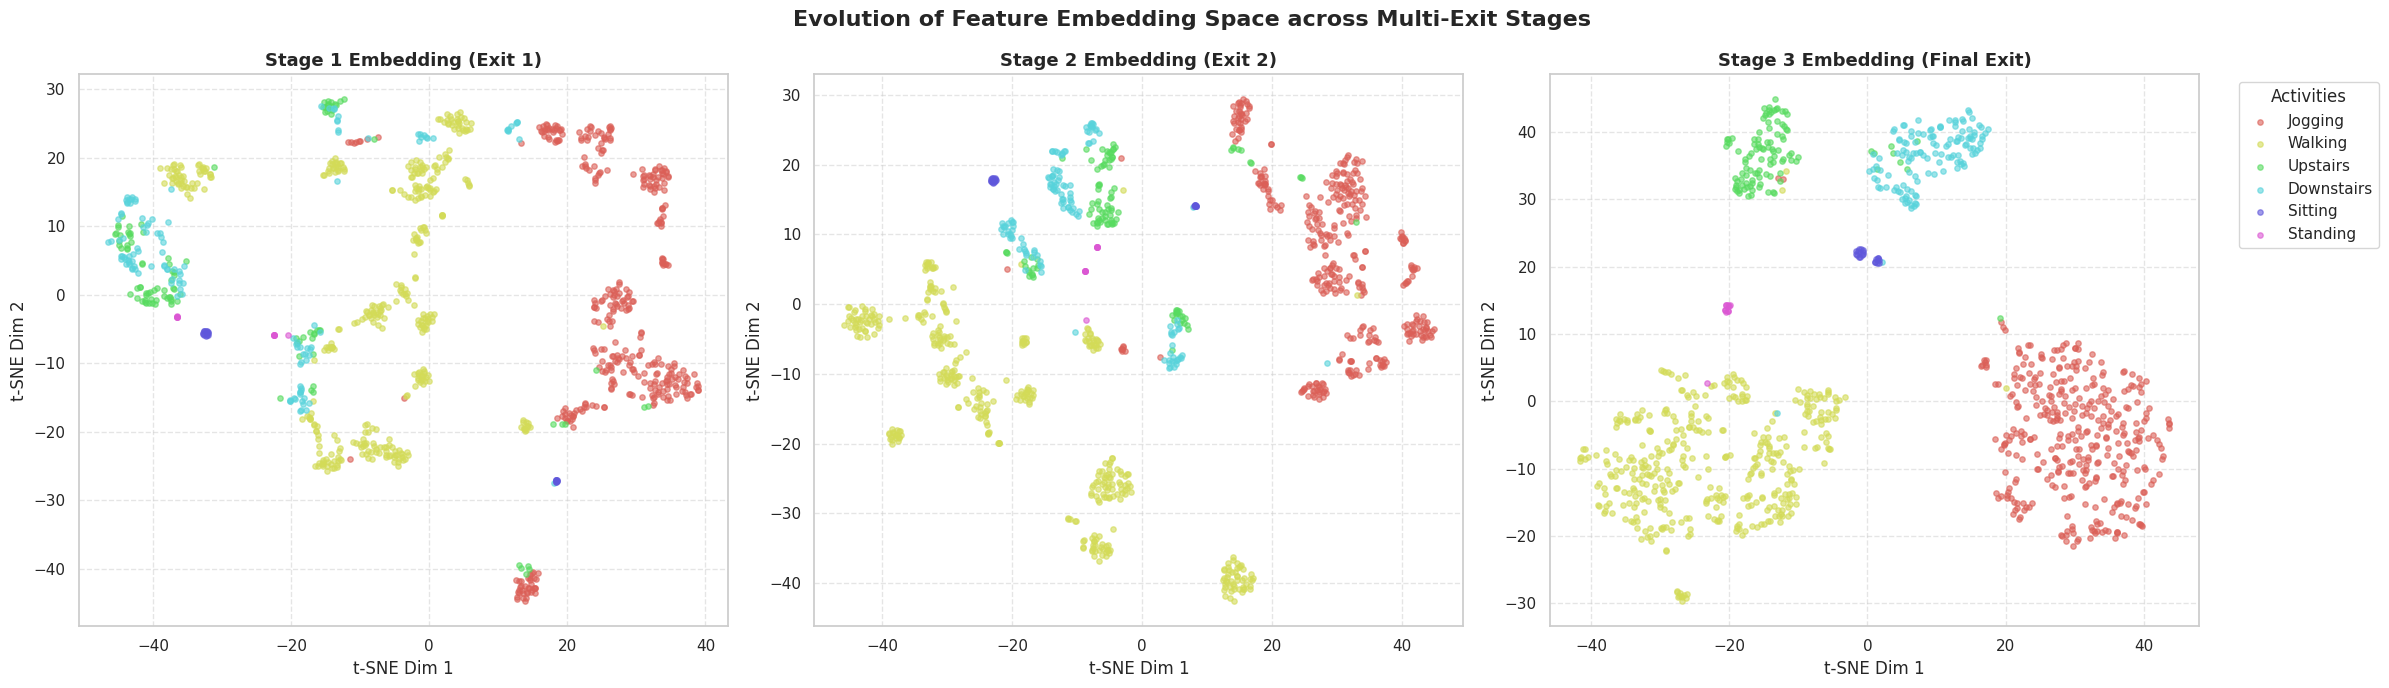

In [54]:
from sklearn.manifold import TSNE


def visualize_multi_exit_tsne(model, data_loader, device):
    model.eval()

    # 각 Stage별 임베딩 벡터와 정답 라벨을 담을 리스트 초기화
    stage1_embeddings = []
    stage2_embeddings = []
    stage3_embeddings = []
    all_labels = []

    print("🚀 각 Multi-Exit Stage의 특징 벡터(Embedding)를 추출 중입니다...")

    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            batch_X = batch_X.to(device)
            batch_size = batch_X.size(0)

            # -----------------------------------------------------------------
            # 1. Stage 1 임베딩 추출 (Exit 1 직전 연산 및 풀링)
            # -----------------------------------------------------------------
            # [Independent 구조 반영] forward와 동일하게 각 단계를 거쳐 특징 맵을 얻음.
            x1 = model.pool1(model.relu1(model.bn1(model.conv1(batch_X))))
            # Exit 1 전용 풀링을 거쳐 1D 벡터로 Flatten
            emb1 = model.exit1_pool(x1).view(batch_size, -1)
            stage1_embeddings.append(emb1.cpu().numpy())

            # -----------------------------------------------------------------
            # 2. Stage 2 임베딩 추출 (Exit 2 직전 연산 및 풀링)
            # -----------------------------------------------------------------
            x2 = model.pool2(model.relu2(model.bn2(model.conv2(x1))))
            emb2 = model.exit2_pool(x2).view(batch_size, -1)
            stage2_embeddings.append(emb2.cpu().numpy())

            # -----------------------------------------------------------------
            # 3. Stage 3 임베딩 추출 (Final Exit 직전 연산 및 풀링)
            # -----------------------------------------------------------------
            x3 = model.pool3(model.relu3(model.bn3(model.conv3(x2))))
            emb3 = model.final_pool(x3).view(batch_size, -1)
            stage3_embeddings.append(emb3.cpu().numpy())

            # -----------------------------------------------------------------
            # 4. 정답 라벨 처리 (원-핫 인코딩 예외 안전장치)
            # -----------------------------------------------------------------
            if len(batch_y.shape) > 1 and batch_y.shape[1] > 1:
                all_labels.append(torch.argmax(batch_y, dim=1).cpu().numpy())
            else:
                all_labels.append(batch_y.cpu().numpy())

    # 배치 데이터 결합
    stage1_embeddings = np.concatenate(stage1_embeddings, axis=0)
    stage2_embeddings = np.concatenate(stage2_embeddings, axis=0)
    stage3_embeddings = np.concatenate(stage3_embeddings, axis=0)
    labels = np.concatenate(all_labels, axis=0)

    print(f"✅ Stage 1 특징 데이터 형태 : {stage1_embeddings.shape}")
    print(f"✅ Stage 2 특징 데이터 형태 : {stage2_embeddings.shape}")
    print(f"✅ Stage 3 특징 데이터 형태 : {stage3_embeddings.shape}")

    # -----------------------------------------------------------------
    # t-SNE 연산 실행 (각 Stage별로 2차원 축소)
    # -----------------------------------------------------------------
    print("\n⏳ [1/3] Stage 1 t-SNE 차원 축소 연산 중...")
    tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
    tsne_s1 = tsne.fit_transform(stage1_embeddings)

    print("⏳ [2/3] Stage 2 t-SNE 차원 축소 연산 중...")
    tsne_s2 = tsne.fit_transform(stage2_embeddings)

    print("⏳ [3/3] Stage 3 t-SNE 차원 축소 연산 중...")
    tsne_s3 = tsne.fit_transform(stage3_embeddings)

    # -----------------------------------------------------------------
    # 시각화 (1x3 서브플롯 구성)
    # -----------------------------------------------------------------
    sns.set_theme(style='whitegrid')
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 7))

    # 클래스 매핑에서 이름 순서대로 정렬 추출
    class_names = [
        k for k, v in sorted(activity_map.items(), key=lambda item: item[1])
    ]
    num_classes = len(class_names)
    colors = sns.color_palette("hls", num_classes)

    # 각 서브플롯별로 클래스 분포 산점도(Scatter) 그리기
    for i in range(num_classes):
        indices = np.where(labels == i)

        # Stage 1 Plot
        ax1.scatter(
            tsne_s1[indices, 0],
            tsne_s1[indices, 1],
            color=colors[i],
            label=class_names[i],
            alpha=0.6,
            s=15,
        )

        # Stage 2 Plot
        ax2.scatter(
            tsne_s2[indices, 0],
            tsne_s2[indices, 1],
            color=colors[i],
            label=class_names[i],
            alpha=0.6,
            s=15,
        )

        # Stage 3 Plot
        ax3.scatter(
            tsne_s3[indices, 0],
            tsne_s3[indices, 1],
            color=colors[i],
            label=class_names[i],
            alpha=0.6,
            s=15,
        )

    # 개별 서브플롯 스타일 설정
    ax1.set_title("Stage 1 Embedding (Exit 1)", fontsize=13, fontweight="bold")
    ax1.set_xlabel("t-SNE Dim 1")
    ax1.set_ylabel("t-SNE Dim 2")
    ax1.grid(True, linestyle="--", alpha=0.5)

    ax2.set_title("Stage 2 Embedding (Exit 2)", fontsize=13, fontweight="bold")
    ax2.set_xlabel("t-SNE Dim 1")
    ax2.set_ylabel("t-SNE Dim 2")
    ax2.grid(True, linestyle="--", alpha=0.5)

    ax3.set_title("Stage 3 Embedding (Final Exit)", fontsize=13, fontweight="bold")
    ax3.set_xlabel("t-SNE Dim 1")
    ax3.set_ylabel("t-SNE Dim 2")
    ax3.grid(True, linestyle="--", alpha=0.5)

    # 공통 범례(Legend) 배치 (가운데 상단 혹은 우측 바깥)
    ax3.legend(
        title="Activities",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        frameon=True,
    )

    plt.suptitle(
        "Evolution of Feature Embedding Space across Multi-Exit Stages",
        fontsize=16,
        fontweight="bold",
        y=0.98,
    )
    plt.tight_layout()
    plt.show()


# --- 시각화 함수 최종 실행 ---
# 최적의 독립 가중치가 로드된 모델 객체와 검증 데이터로더 전달
visualize_multi_exit_tsne(best_model, val_loader, device)

📌 혼동 행렬 (Confusion Matrix)

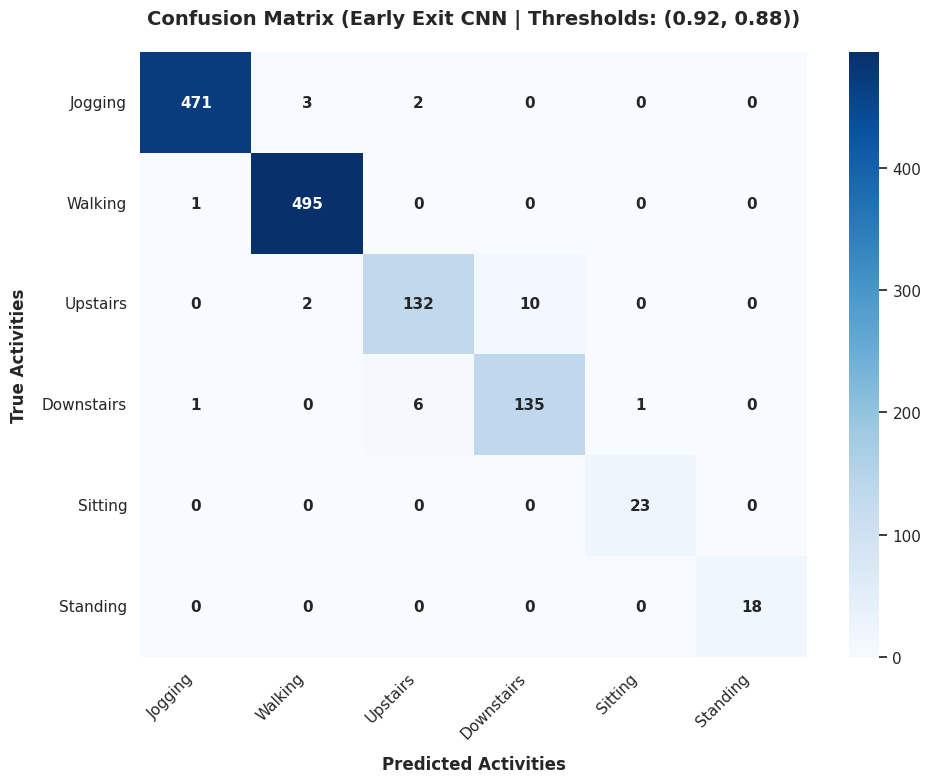

In [55]:
# =====================================================================
# 1. 혼동 행렬(Confusion Matrix) 계산
# =====================================================================
# 앞서 DYNAMIC_THRESHOLDS를 통해 구한 y_pred와 y_test를 비교
cm = confusion_matrix(y_test, y_pred)

# activity_map에서 인덱스 순서대로 정확한 액티비티 명칭 추출
class_names = [k for k, v in sorted(activity_map.items(), key=lambda item: item[1])]

# =====================================================================
# 2. Seaborn Heatmap을 이용한 시각화 설정
# =====================================================================
plt.figure(figsize=(10, 8))

# xticklabels, yticklabels에 class_names를 직접 주입하면 위치 조절이 더 깔끔해진다고 함.
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={"size": 11, "weight": "bold"} # 숫자 가독성 향상
)

# =====================================================================
# 3. 축 레이블 및 타이틀 설정 (Multi-Exit 반영)
# =====================================================================
# 어떤 임계값 조건에서 나온 혼동 행렬인지 제목에 명시
plt.title(f'Confusion Matrix (Early Exit CNN | Thresholds: {DYNAMIC_THRESHOLDS})', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Predicted Activities', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('True Activities', fontsize=12, fontweight='bold', labelpad=10)

# 글자가 잘리지 않고 중앙에 예쁘게 걸리도록 폰트 및 정렬 보정
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()